# Customer Query Chatbot for Rale Clothing Co.
### An Intent Classification Approach
**CS5101 Natural Language Processing**
Semester 2, 2025-2026

## 1. Introduction and Problem Definition
*[To be written by Ando]*

### 1.1 Introduction

The rise of social media commerce has significantly changed how small businesses
interact with their customers. Many local brands, particularly in the Philippines,
now rely heavily on platforms like Facebook and Instagram to market their products
and respond to customer inquiries. However, as a brand grows, manually responding
to every customer message becomes increasingly time-consuming and inconsistent.
This is especially true for small clothing brands that operate with limited staff
but receive a high volume of repetitive questions about prices, sizes, orders, and
promotions.

Rale Clothing Co. is a Cebu-based clothing brand that operates primarily through
social media. Like many local businesses of its kind, it receives customer queries
regularly through its online platforms. These queries range from simple product
inquiries to questions about payment methods and order status. Responding to each
one manually takes time away from other business operations, and delayed responses
can lead to lost sales and poor customer experience. An automated system that can
understand and respond to these queries would be a practical and valuable solution
for a brand like Rale Clothing Co.

This project proposes the development of a customer query chatbot for Rale Clothing
Co. using Natural Language Processing (NLP) techniques. Rather than building a
full AI-powered conversational agent, the system follows a more manageable and
explainable approach: intent classification paired with a rule-based response
system. The chatbot classifies an incoming customer message into one of ten
predefined intent categories, then returns a pre-written response corresponding
to that intent. This design keeps the system lightweight, interpretable, and
appropriate for a small business context.

A key challenge this project addresses is the multilingual nature of Filipino
customer communication. Customers of local brands like Rale Clothing Co. do not
always write in English. They often write in Tagalog, Cebuano, or a mix of
languages within a single message, a phenomenon commonly known as code-switching.
To reflect this reality, the dataset used in this project was manually constructed
to include queries written in English, Tagalog, and Cebuano. This makes the
chatbot more representative of actual customer behavior and adds a layer of
complexity that standard NLP pipelines are not always equipped to handle out of
the box.

### 1.2 Problem Definition

This project follows the complete NLP pipeline as required by the course. This
includes data collection, text preprocessing, feature engineering, model
development, and evaluation. For feature extraction, both Bag-of-Words and TF-IDF
representations are implemented and compared. Three machine learning classifiers
are trained and evaluated: Naive Bayes, Logistic Regression, and Support Vector
Machine (SVM). Each classifier is tested against both feature extraction methods,
resulting in six model-feature combinations that are compared against each other
using standard classification metrics.

The input to the system is a raw text message typed by a customer, written in any
of the three supported languages. The output is a predicted intent label, which
the rule-based response layer then maps to an appropriate reply from Rale Clothing
Co. The primary evaluation metric is the F1-score, chosen because it balances
precision and recall and is well-suited for multi-class classification tasks where
class balance matters. Accuracy, precision, recall, and confusion matrices are
also reported to provide a comprehensive view of each model's performance.

This project is relevant not only as an academic exercise but also as a practical
demonstration of how NLP can be applied to real-world, local business problems.
It highlights the potential of even simple machine learning classifiers to
automate meaningful tasks when paired with a well-constructed dataset and a clear
problem definition. The insights gained from this project, including the
challenges of multilingual preprocessing and model comparison, contribute to a
broader understanding of NLP in the context of Philippine languages and local
commerce.

## 2. Data Loading and Exploration
*[To be written by Abrenica]*


In [40]:
# Import libraries for data handling and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
# Load the CSV dataset into a pandas DataFrame
df = pd.read_csv("rale_clothing_intent_dataset.csv")

In [42]:
# Display the first 10 rows of the dataset
df.head(10)

,text,intent,language
0,Hey there! Just wanted to check out your store.,greeting,English
1,Hi! Is anyone available to help me out?,greeting,English
2,Hello! Just browsing around your page.,greeting,English
3,Good morning! Got a few questions about your s...,greeting,English
4,Hey what's up? Saw your page and wanted to ask...,greeting,English
5,Hi there new customer here! Hope you can help me.,greeting,English
6,Heyyy just found your store online is someone ...,greeting,English
7,Good afternoon! Excited to shop here for the f...,greeting,English
8,Sup just dropped by to check your stuff out.,greeting,English
9,Hey team! Love the brand already just from the...,greeting,English


In [43]:
# Show dataset information such as columns and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   text      350 non-null    object
 1   intent    350 non-null    object
 2   language  350 non-null    object
dtypes: object(3)
memory usage: 8.3+ KB


In [44]:
# Show dataset information such as columns and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   text      350 non-null    object
 1   intent    350 non-null    object
 2   language  350 non-null    object
dtypes: object(3)
memory usage: 8.3+ KB


In [45]:
# Check for missing values in each column
print(df.isnull().sum())

text        0
intent      0
language    0
dtype: int64


In [46]:
# Count duplicate rows in the dataset
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [47]:
# Count the number of samples per intent
intent_counts = df['intent'].value_counts()

print(intent_counts)

intent
greeting           35
product_inquiry    35
price_inquiry      35
size_and_fit       35
order_placement    35
order_status       35
payment_methods    35
store_contact      35
return_exchange    35
promotions         35
Name: count, dtype: int64


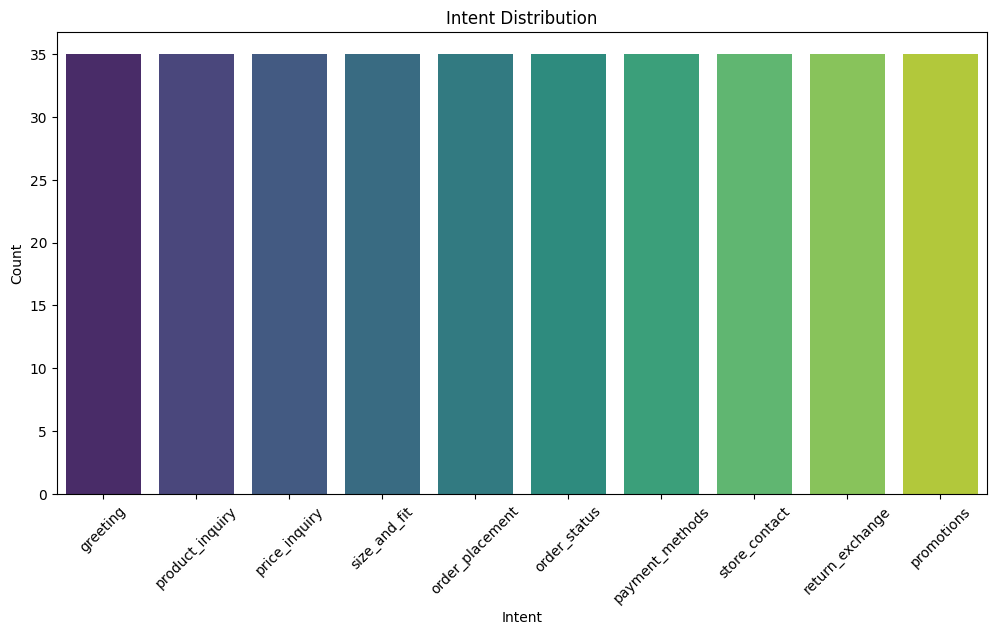

In [48]:
# Create a bar chart for intent distribution
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='intent',
    order=df['intent'].value_counts().index,
    palette='viridis'
)

# Add chart labels and title
plt.title("Intent Distribution")
plt.xlabel("Intent")
plt.ylabel("Count")
plt.xticks(rotation=45)

# Display the graph
plt.show()

In [49]:
# Count the number of samples per language
language_counts = df['language'].value_counts()

print(language_counts)

language
English    111
Tagalog    110
Cebuano    109
mixed       20
Name: count, dtype: int64


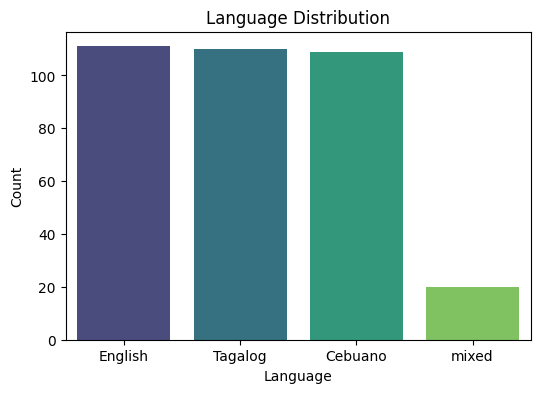

In [50]:
# Create a bar chart for language distribution
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='language',
    order=df['language'].value_counts().index,
    palette='viridis'
)

# Add chart labels and title
plt.title("Language Distribution")
plt.xlabel("Language")
plt.ylabel("Count")

# Display the graph
plt.show()

In [51]:
# Display 10 random samples from the dataset
df.sample(10)

,text,intent,language
117,Naa ba moy 2XL para sa plus size?,size_and_fit,Cebuano
261,Unsa inyong return policy? Dili ko ganahan sa ...,return_exchange,Cebuano
274,Are there any bundle deals happening right now?,promotions,English
255,Hanggang kailan pwede mag-request ng exchange?,return_exchange,Tagalog
78,Presyo ng vintage shirt? Mas mahal ba yan?,price_inquiry,Tagalog
83,Pinaka-barato nga shirt ninyo pila?,price_inquiry,Cebuano
294,May promo ba para sa bag-ong customer?,promotions,Cebuano
284,May promo ba para sa first-time buyers?,promotions,Tagalog
292,Free shipping ba kung dako ang order?,promotions,Cebuano
229,Saan kayo mahahanap sa social media?,store_contact,Tagalog


In [52]:
# Display all unique intent labels
print(df['intent'].unique())

['greeting' 'product_inquiry' 'price_inquiry' 'size_and_fit'
 'order_placement' 'order_status' 'payment_methods' 'store_contact'
 'return_exchange' 'promotions']


In [53]:
# Display all unique language labels
print(df['language'].unique())

['English' 'Tagalog' 'Cebuano' 'mixed']


### Summary

The dataset contains multilingual customer queries for the Rale Clothing Co. chatbot. The dataset consists of 350 rows and 3 columns: text, intent, and language. No missing values or duplicate rows were found, indicating good dataset quality and integrity.

The dataset is balanced across all 10 intent classes, with each intent containing 35 samples. Balanced class distribution is important in intent classification tasks because it minimizes model bias and improves classification fairness.

The dataset includes English, Tagalog, Cebuano, and mixed-language customer queries. The inclusion of multilingual and code-switched samples improves the chatbot’s ability to handle realistic Filipino customer interactions.

## 3. Text Preprocessing
*[To be written by Abrenica]*

In [54]:
# ============================================
# TEXT PREPROCESSING - LIBRARY IMPORTS
# ============================================

import pandas as pd
import numpy as np
import re
import nltk

# NLTK modules for tokenization, stopwords, and lemmatization
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Suppress warnings for cleaner notebook output
import warnings
warnings.filterwarnings('ignore')

In [55]:
# Download tokenizer model
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab')

# Download English stopwords corpus
nltk.download('stopwords', quiet=True)

# Download WordNet lexical database for lemmatization
nltk.download('wordnet', quiet=True)

# Download Open Multilingual WordNet
nltk.download('omw-1.4', quiet=True)

print("All required NLTK resources downloaded successfully.")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


All required NLTK resources downloaded successfully.


In [56]:
# CREATE STOPWORD LISTS
# Load NLTK's built-in English stopword list
english_stopwords = set(stopwords.words('english'))

# Custom Tagalog stopwords (particles, fillers, connectors only)
tagalog_stopwords = {
    'ang', 'ng', 'mga', 'sa', 'na', 'ay', 'at', 'ko', 'mo', 'si', 'ni',
    'kay', 'para', 'dito', 'diyan', 'doon', 'ito', 'iyan', 'noon',
    'po', 'opo', 'ho', 'oho', 'ba', 'pa', 'lang', 'lamang', 'din',
    'rin', 'daw', 'raw', 'kasi', 'kung', 'kapag', 'pag', 'eh', 'ah',
    'sila', 'kami', 'tayo', 'ikaw', 'ka', 'nila', 'namin', 'natin'
}

# Custom Cebuano stopwords (particles, fillers, connectors only)
cebuano_stopwords = {
    'ang', 'ng', 'mga', 'sa', 'kay', 'ug', 'og', 'mao', 'ako', 'imo',
    'iya', 'kami', 'kamo', 'sila', 'kini', 'kana', 'kadto', 'diri',
    'dinhi', 'didto', 'man', 'ra', 'ba', 'pa', 'lang', 'unta', 'unta',
    'aron', 'kay', 'ni', 'nila', 'nako', 'nimo', 'niya', 'nato', 'namo'
}

# Combine all stopwords into a single set
all_stopwords = english_stopwords.union(tagalog_stopwords).union(cebuano_stopwords)

print(f"English stopwords: {len(english_stopwords)}")
print(f"Tagalog stopwords: {len(tagalog_stopwords)}")
print(f"Cebuano stopwords: {len(cebuano_stopwords)}")
print(f"Total combined stopwords: {len(all_stopwords)}")

English stopwords: 198
Tagalog stopwords: 45
Cebuano stopwords: 34
Total combined stopwords: 264


In [57]:
# Initialize WordNet lemmatizer
lemmatizer = WordNetLemmatizer()

print("WordNet Lemmatizer initialized.")

WordNet Lemmatizer initialized.


In [58]:
# DEFINE PREPROCESSING FUNCTION
def preprocess_text(text):
    """
    Preprocesses multilingual customer query text for intent classification.

    Args:
        text (str): Raw customer query text

    Returns:
        str: Cleaned and standardized text
    """

    # Handle non-string or missing values
    if not isinstance(text, str):
        return ""

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize text into words
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in all_stopwords]

    # Lemmatize tokens
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Rejoin tokens into cleaned text string
    cleaned_text = ' '.join(tokens)

    return cleaned_text


print("preprocess_text() function defined successfully.")

preprocess_text() function defined successfully.


In [59]:
# LOAD DATASET

# Load the customer query dataset
df = pd.read_csv('rale_clothing_intent_dataset.csv')

print("Dataset loaded successfully.")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
print(f"Languages: {df['language'].value_counts().to_dict()}")
print(f"Intents: {df['intent'].nunique()} unique classes")
df.head()

Dataset loaded successfully.
Shape: 350 rows × 3 columns
Columns: ['text', 'intent', 'language']
Languages: {'English': 111, 'Tagalog': 110, 'Cebuano': 109, 'mixed': 20}
Intents: 10 unique classes


,text,intent,language
0,Hey there! Just wanted to check out your store.,greeting,English
1,Hi! Is anyone available to help me out?,greeting,English
2,Hello! Just browsing around your page.,greeting,English
3,Good morning! Got a few questions about your s...,greeting,English
4,Hey what's up? Saw your page and wanted to ask...,greeting,English


In [60]:
# APPLY PREPROCESSING

# Create new column with preprocessed text
df['cleaned_text'] = df['text'].apply(preprocess_text)

print("Preprocessing applied to all rows.")
print(f"New column 'cleaned_text' created.")

Preprocessing applied to all rows.
New column 'cleaned_text' created.


In [61]:
# DISPLAY SAMPLE COMPARISONS

print("=" * 90)
print(f"{'LANGUAGE':<12} {'ORIGINAL TEXT':<45} {'CLEANED TEXT':<30}")
print("=" * 90)

# Display first 12 rows showing all language types
for idx, row in df.head(12).iterrows():
    original = str(row['text'])[:42] + '...' if len(str(row['text'])) > 42 else str(row['text'])
    cleaned = row['cleaned_text'][:27] + '...' if len(row['cleaned_text']) > 27 else row['cleaned_text']
    print(f"{row['language']:<12} {original:<45} → {cleaned:<30}")

print("=" * 90)

LANGUAGE     ORIGINAL TEXT                                 CLEANED TEXT                  
English      Hey there! Just wanted to check out your s... → hey wanted check store        
English      Hi! Is anyone available to help me out?       → hi anyone available help      
English      Hello! Just browsing around your page.        → hello browsing around page    
English      Good morning! Got a few questions about yo... → good morning got question s...
English      Hey what's up? Saw your page and wanted to... → hey saw page wanted ask som...
English      Hi there new customer here! Hope you can h... → hi new customer hope help     
English      Heyyy just found your store online is some... → heyyy found store online so...
English      Good afternoon! Excited to shop here for t... → good afternoon excited shop...
English      Sup just dropped by to check your stuff ou... → sup dropped check stuff       
English      Hey team! Love the brand already just from... → hey team love brand a

In [62]:
# QUALITY CHECK - EMPTY TEXTS

# Count empty cleaned texts
empty_count = (df['cleaned_text'].str.strip() == '').sum()

print(f"Rows with empty cleaned_text: {empty_count}")

if empty_count > 0:
    print("\nWarning: Some queries produced empty cleaned text.")
    display(df[df['cleaned_text'].str.strip() == ''][['text', 'language', 'intent']])
else:
    print("All queries retained content after preprocessing.")

Rows with empty cleaned_text: 0
All queries retained content after preprocessing.


## 4. Feature Extraction (BoW and TF-IDF)
*[To be written by Ruelan]*

## 5. Model Training (Naive Bayes, Logistic Regression, SVM)
*[To be written by Montebon]*

## 6. Evaluation and Model Comparison
*[To be written by Montebon]*

## 7. Error Analysis
*[To be written by Ruelan]*

## 8. Rule-Based Response System + Live Demo
*[To be written by Abrenica]*

## 9. Conclusions, Limitations, and Recommendations
*[To be written by Ando]*

## 10. Member Contributions

| No. | Name | Task | Contribution (%) |
|---|---|---|---|
| 1 | Abrenica | | |
| 2 | Ando | | |
| 3 | Montebon | | |
| 4 | Ruelan | | |
| | | **Total** | **100%** |